# Product Analysis
Source: products_clean.parquet

Covers: categories, subcategories, brands, margin, pricing

### Imports & setup

In [1]:
import pandas as pd
from src.analysis import products
from src.viz import base

### Load data

In [2]:
df = pd.read_parquet("../data/processed/products_clean.parquet")
print(df.shape)
df.head()

(2517, 13)


,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category,Margin USD,Margin Pct,Is Premium Product
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio,6.37,49.04,False
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio,6.37,49.04,False
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio,7.12,49.04,False
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio,10.57,49.00,False
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio,10.57,49.00,False


## Category Breakdown

,Category,count,pct
0,Home Appliances,661,26.26
1,Computers,606,24.08
2,Cameras and camcorders,372,14.78
3,Cell phones,285,11.32
4,TV and Video,222,8.82
5,Games and Toys,166,6.60
6,Audio,115,4.57
7,"Music, Movies and Audio Books",90,3.58


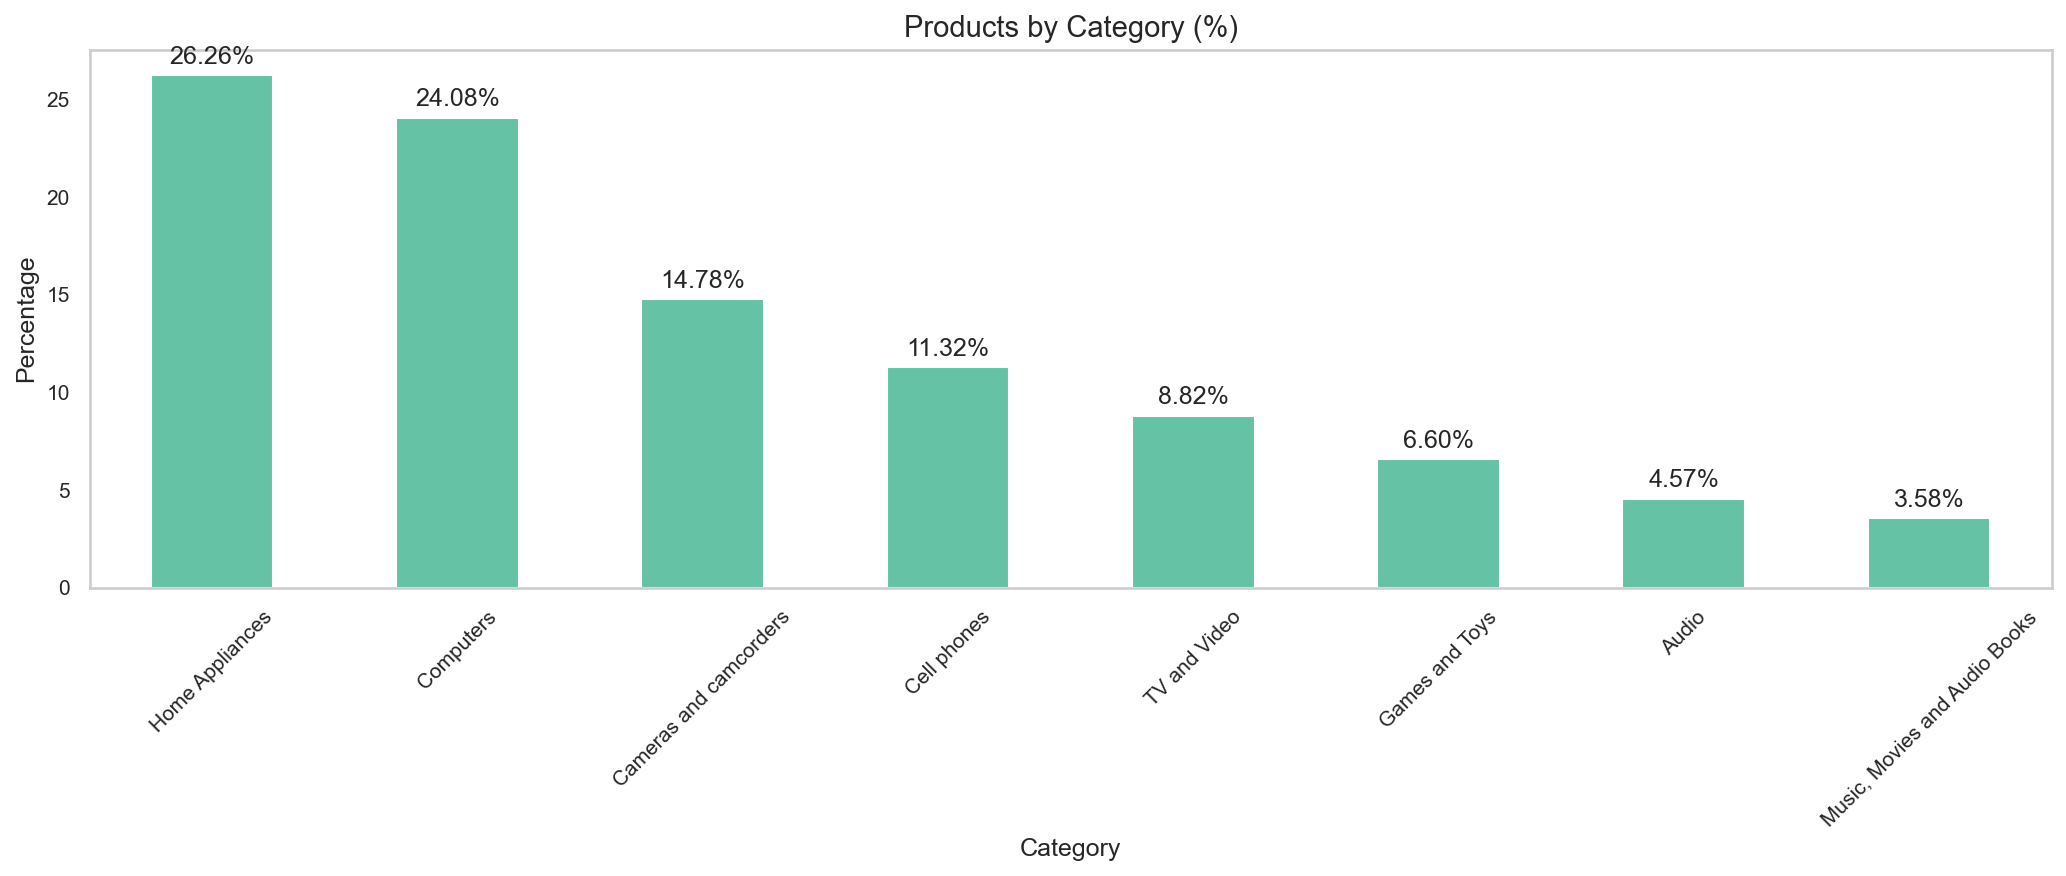

In [3]:
cat_split = products.category_split(df)
display(cat_split)
fig, ax = base.bar(
    cat_split.set_index("Category")["pct"],
    title="Products by Category (%)",
    xlabel="Category",
    ylabel="Percentage",
    is_pct=True,
    filename="products_category_split.png"
)

display(fig)

## Subcategory Breakdown

,Subcategory,count,pct
0,Computers Accessories,201,7.99
1,Lamps,158,6.28
2,Download Games,120,4.77
3,Projectors & Screens,103,4.09
4,Camcorders,103,4.09
5,Microwaves,102,4.05
6,Smart phones & PDAs,101,4.01
7,"Printers, Scanners & Fax",101,4.01
8,Digital SLR Cameras,100,3.97
9,Digital Cameras,100,3.97


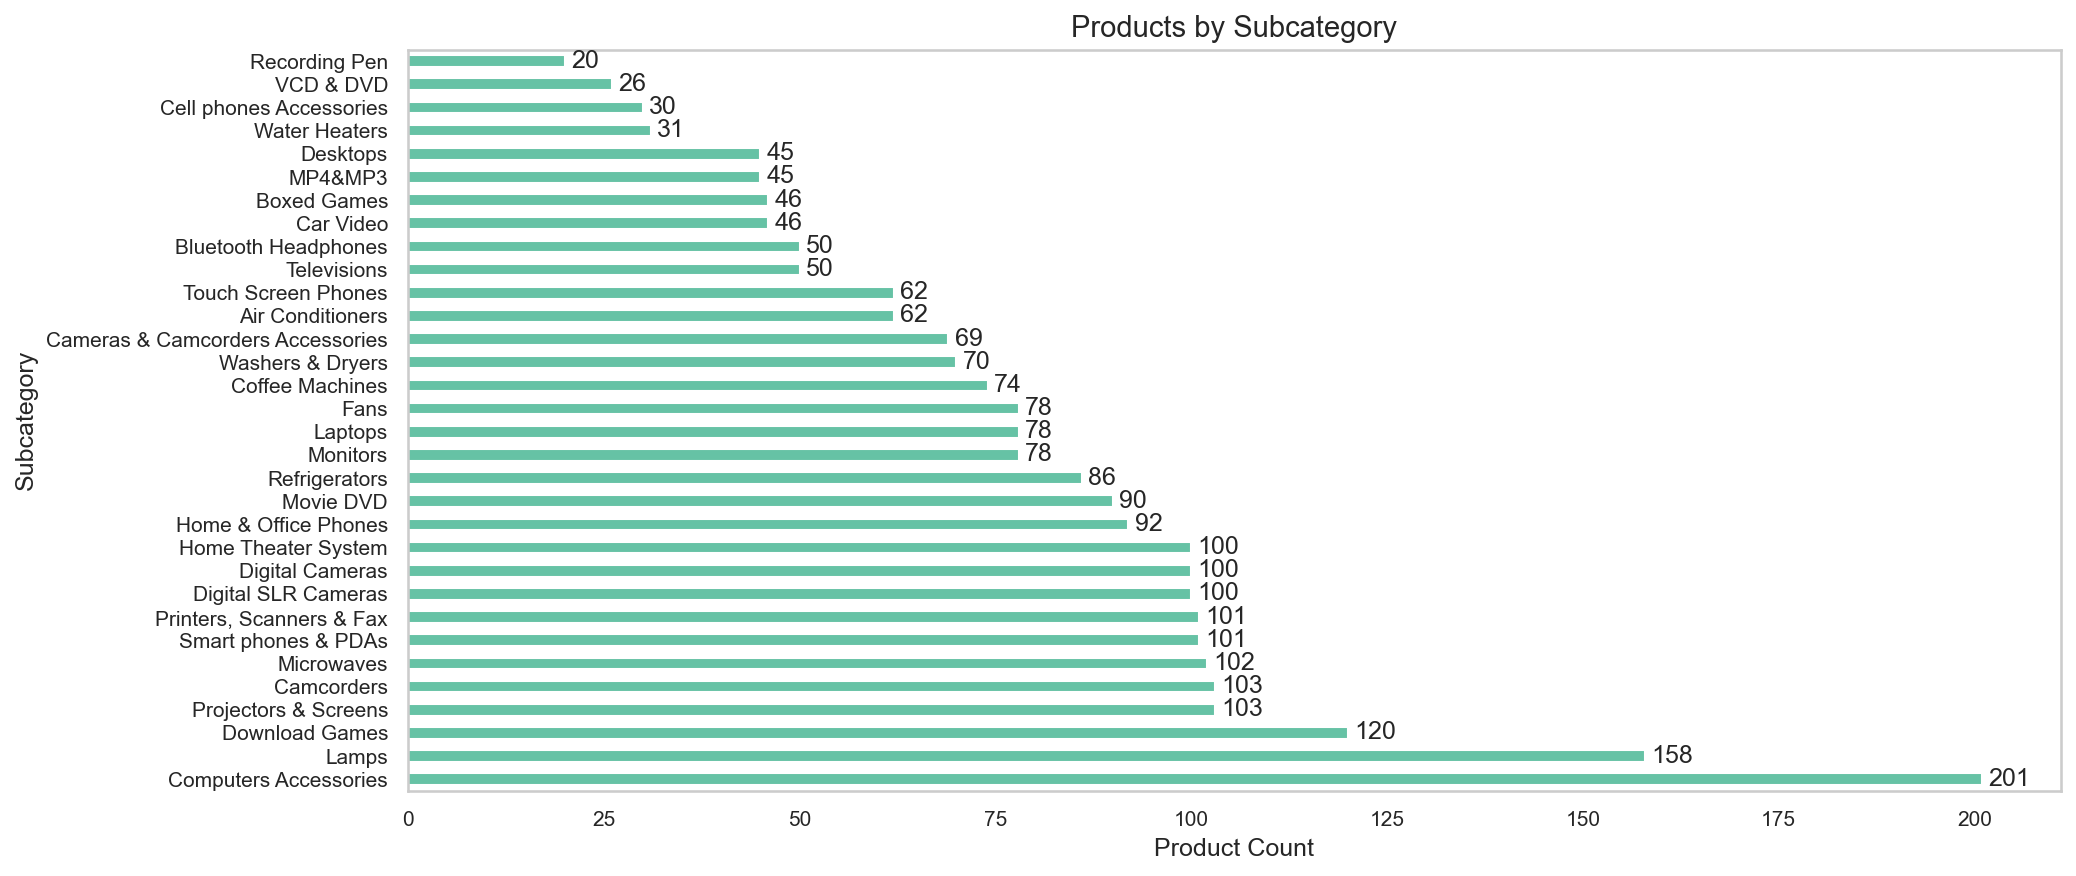

In [4]:
subcat_split = products.subcategory_split(df)
display(subcat_split)
fig, ax = base.horizontal_bar(
    subcat_split.set_index("Subcategory")["count"],
    title="Products by Subcategory",
    xlabel="Product Count",
    ylabel="Subcategory",
    filename="products_subcategory_split.png"
)

display(fig)

## Top Brands by Product Count

Brand
Contoso                 710
Fabrikam                267
Litware                 264
Proseware               244
Adventure Works         192
Southridge Video        192
Wide World Importers    173
The Phone Company       152
Tailspin Toys           144
A. Datum                132
dtype: int64

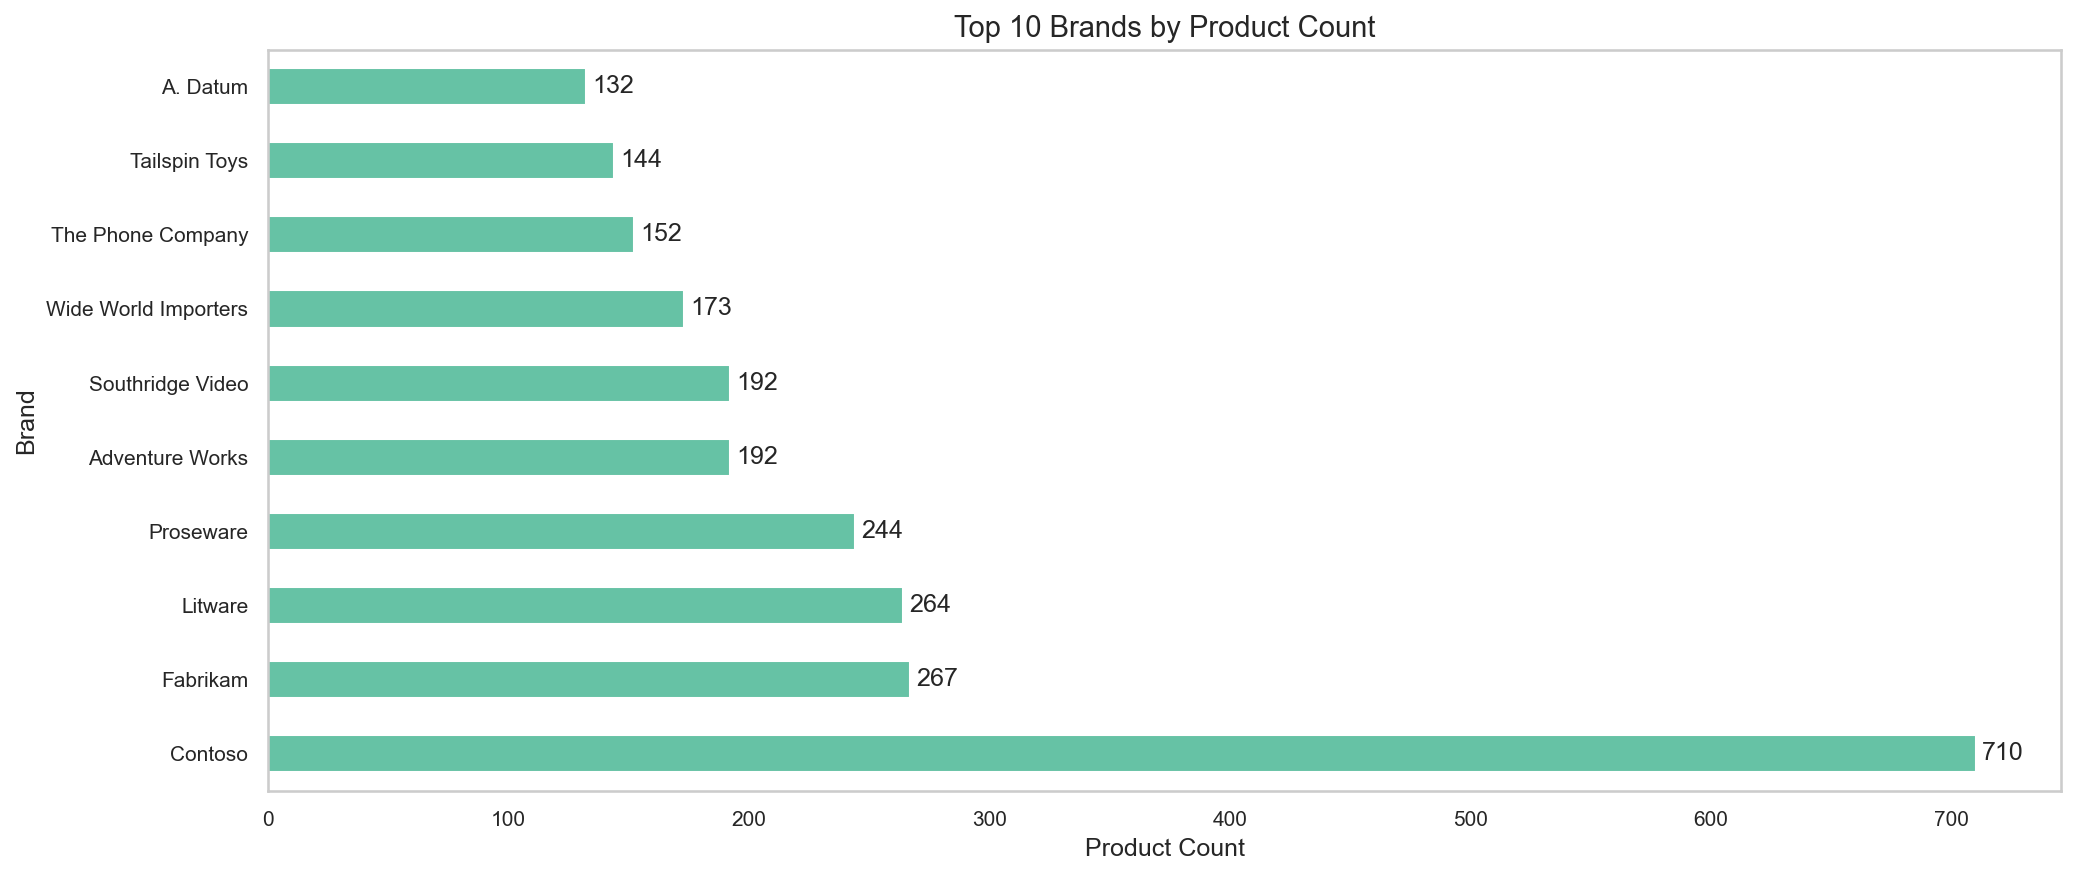

In [5]:
top_brands = products.top_brands_by_count(df, n=10)
display(top_brands)
fig, ax = base.horizontal_bar(
    top_brands,
    title="Top 10 Brands by Product Count",
    xlabel="Product Count",
    ylabel="Brand",
    filename="products_top_brands_count.png"
)

display(fig)

## Top Brands by Average Margin

Brand
A. Datum                58.132197
The Phone Company       55.792566
Fabrikam                55.445393
Proseware               55.419303
Northwind Traders       55.199574
Wide World Importers    55.183237
Adventure Works         54.691510
Contoso                 54.165803
Southridge Video        53.738281
Litware                 53.056061
Name: Margin Pct, dtype: float64

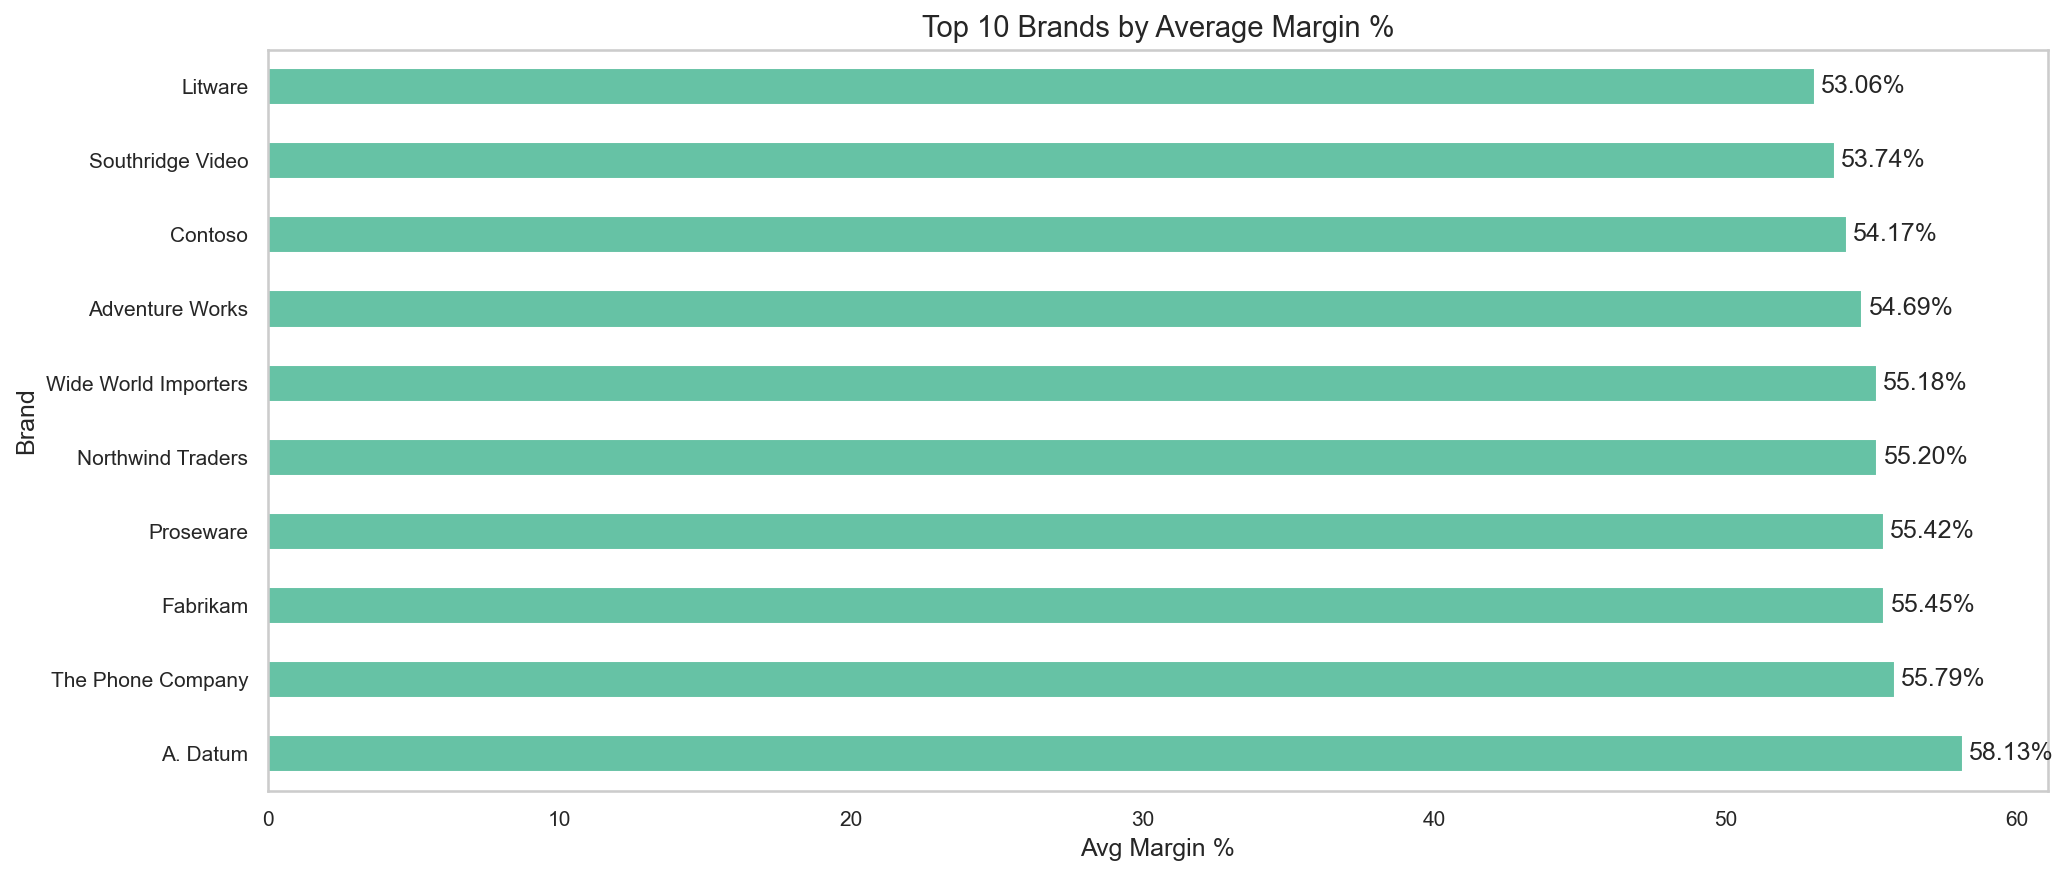

In [6]:
brands_margin = products.top_brands_by_margin(df, n=10)
display(brands_margin)
fig, ax = base.horizontal_bar(
    brands_margin,
    title="Top 10 Brands by Average Margin %",
    xlabel="Avg Margin %",
    ylabel="Brand",
    is_pct=True,
    filename="products_top_brands_margin.png"
)

display(fig)

## Margin Distribution

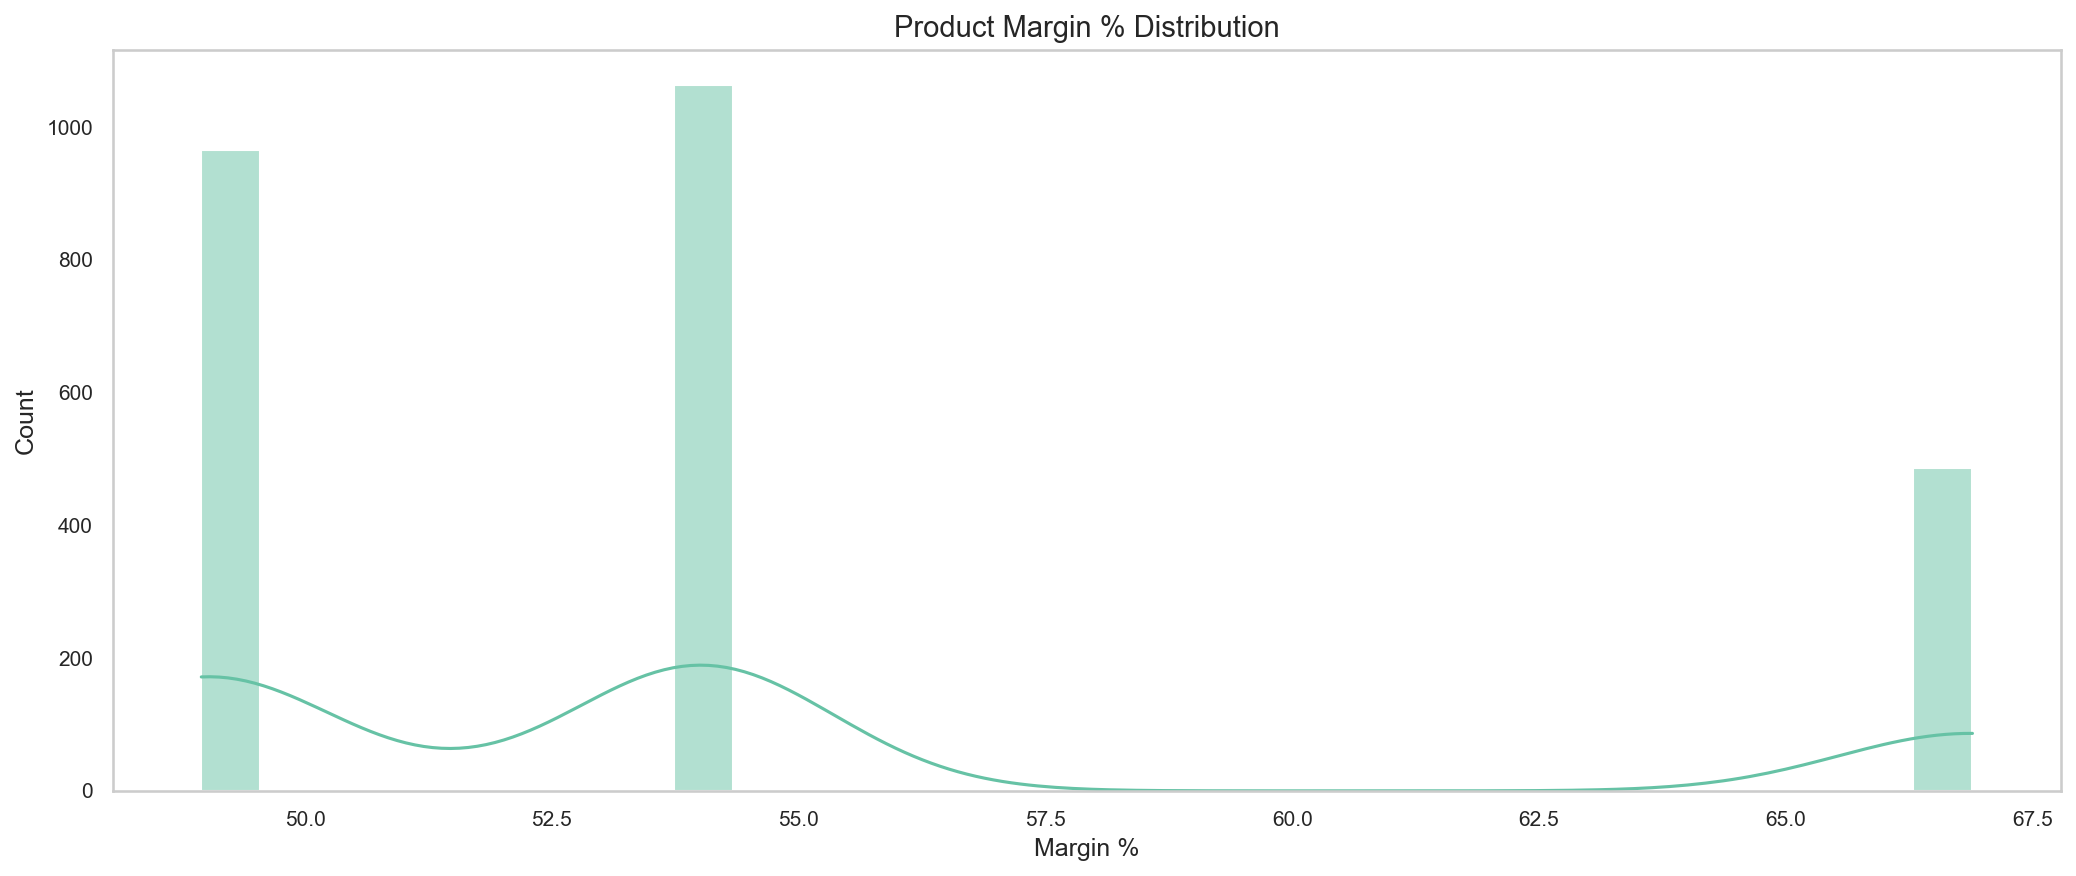

In [7]:
margin_data = products.margin_distribution(df)
fig, ax = base.histogram(
    margin_data,
    title="Product Margin % Distribution",
    xlabel="Margin %",
    ylabel="Count",
    bins=30,
    filename="products_margin_distribution.png"
)
display(fig)

## Average Margin by Category

,Category,Margin Pct
0,Audio,55.28
1,Cameras and camcorders,56.85
2,Cell phones,54.91
3,Computers,54.77
4,Games and Toys,52.16
5,Home Appliances,53.36
6,"Music, Movies and Audio Books",57.24
7,TV and Video,53.89


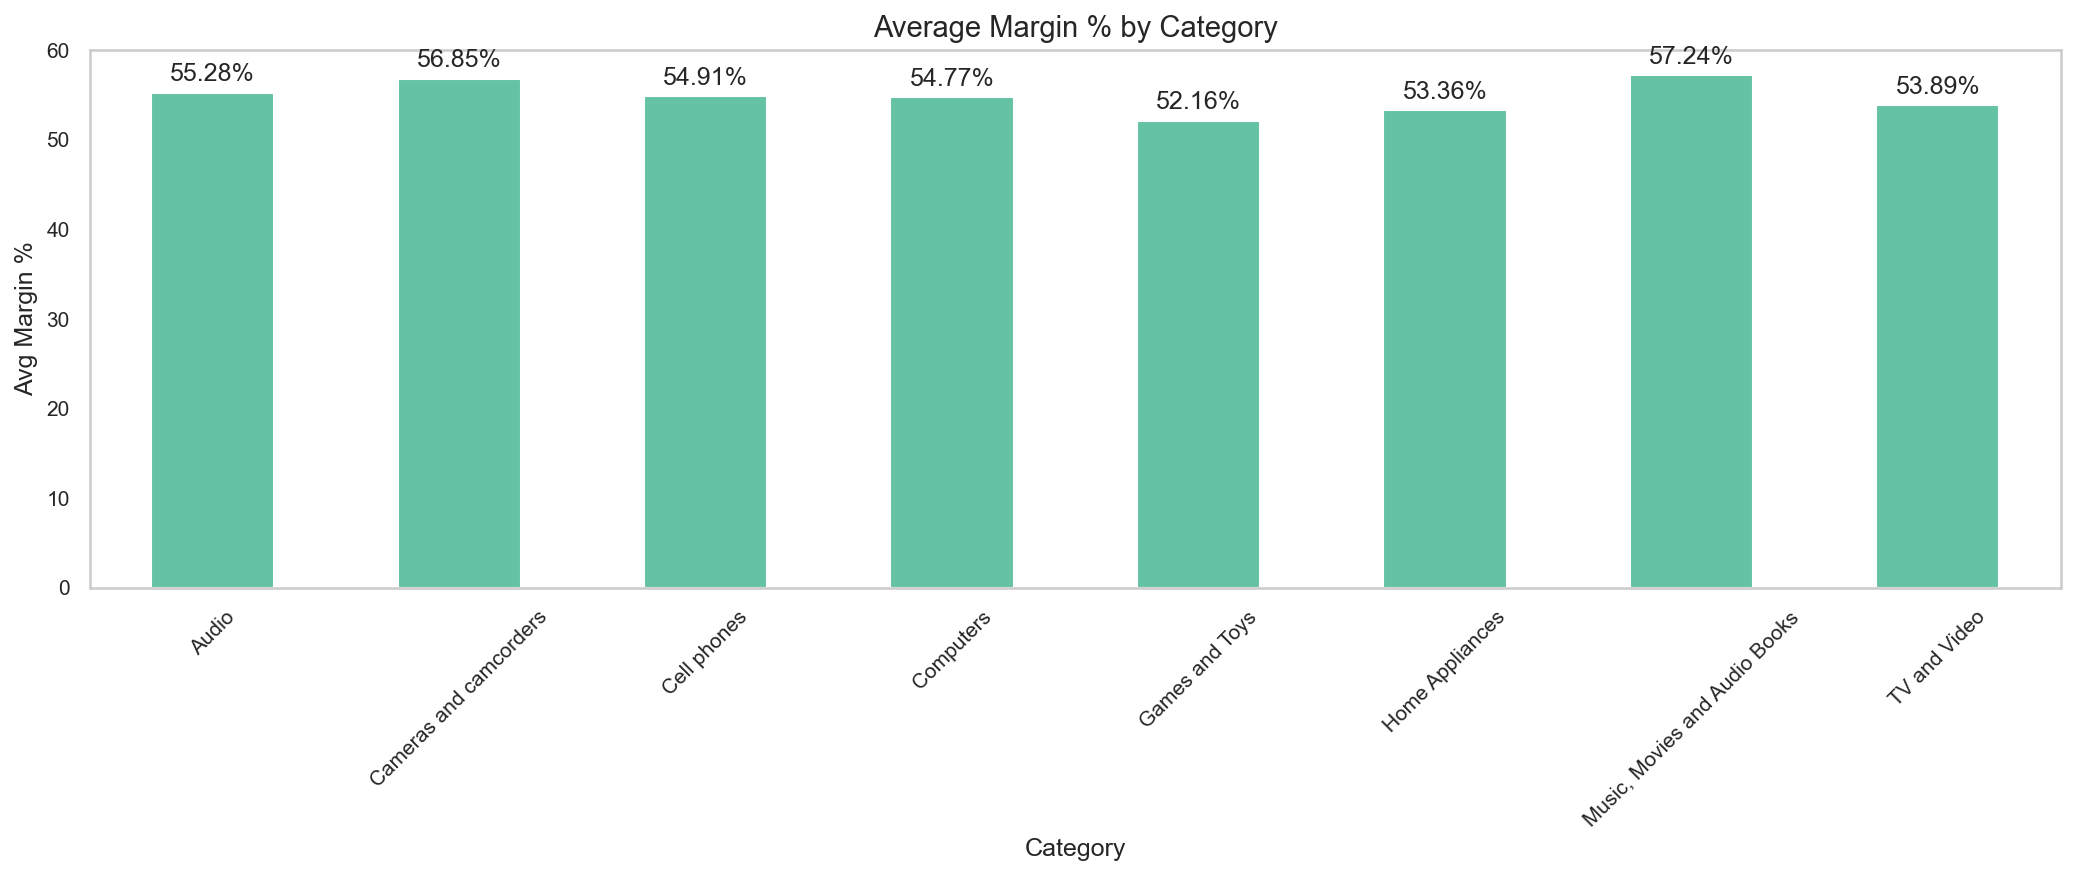

In [8]:
margin_cat = products.margin_by_category(df)
display(margin_cat)
fig, ax = base.bar(
    margin_cat.set_index("Category")["Margin Pct"],
    title="Average Margin % by Category",
    xlabel="Category",
    ylabel="Avg Margin %",
    is_pct=True,
    filename="products_margin_by_category.png"
)
display(fig)

## Average Margin by Category

,Category,Margin Pct
0,Audio,55.28
1,Cameras and camcorders,56.85
2,Cell phones,54.91
3,Computers,54.77
4,Games and Toys,52.16
5,Home Appliances,53.36
6,"Music, Movies and Audio Books",57.24
7,TV and Video,53.89


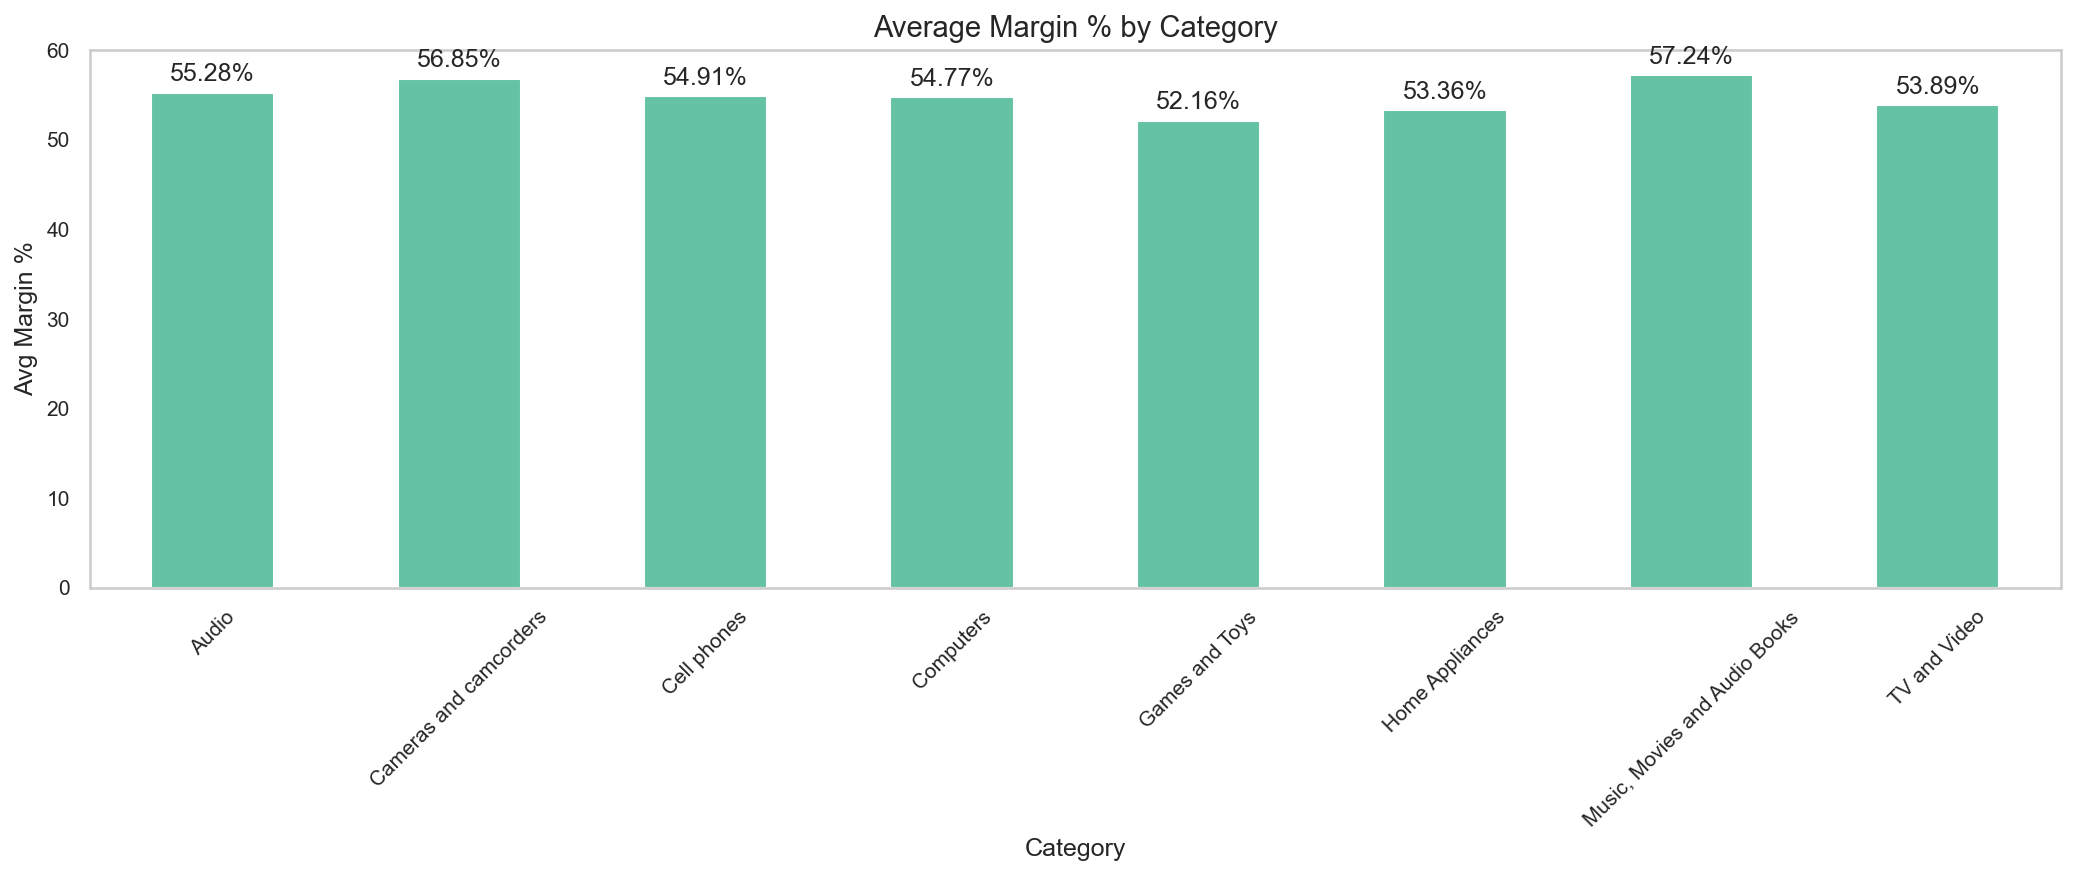

In [9]:
margin_cat = products.margin_by_category(df)
display(margin_cat)
fig, ax = base.bar(
    margin_cat.set_index("Category")["Margin Pct"],
    title="Average Margin % by Category",
    xlabel="Category",
    ylabel="Avg Margin %",
    is_pct=True,
    filename="products_margin_by_category.png"
)

display(fig)

## Price Distribution

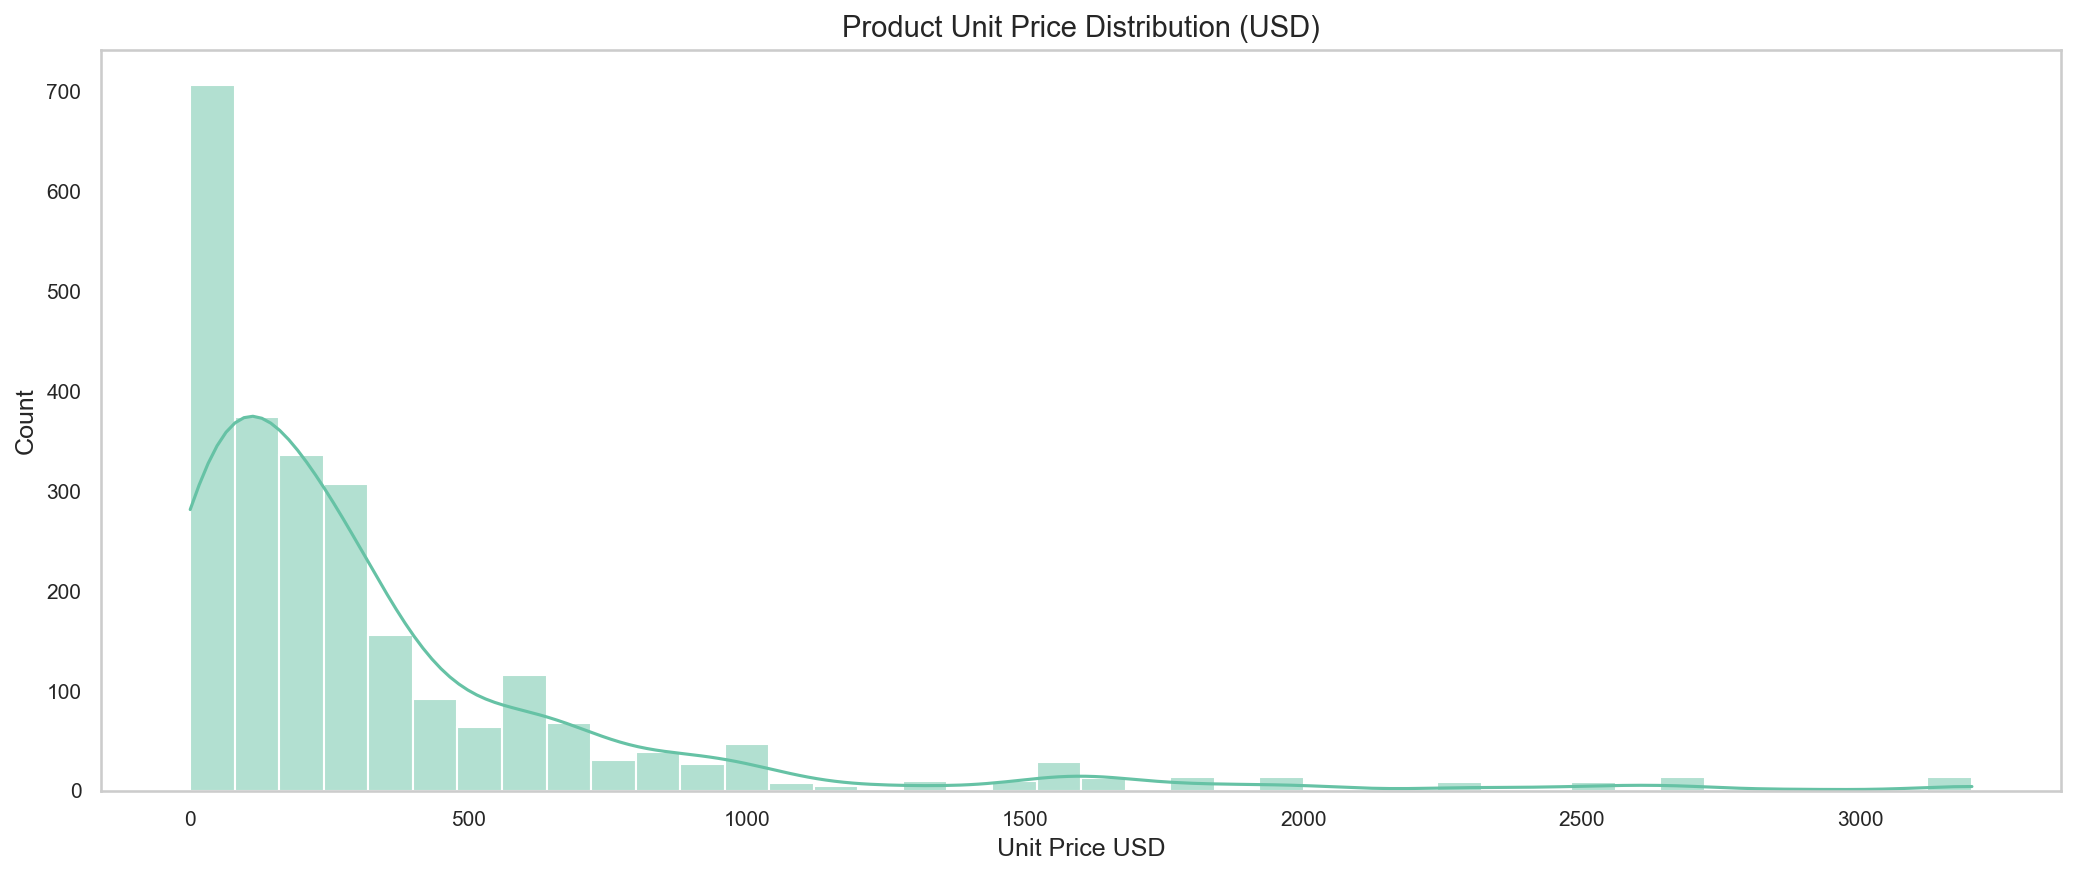

In [10]:
fig, ax = base.histogram(
    products.price_distribution(df),
    title="Product Unit Price Distribution (USD)",
    xlabel="Unit Price USD",
    ylabel="Count",
    bins=40,
    filename="products_price_distribution.png"
)

display(fig)

## Margin Summary Statistics

In [11]:
display(products.margin_stats(df))

count    2517.00
mean       54.59
std         6.42
min        48.95
25%        49.02
50%        54.01
75%        54.02
max        66.89
Name: Margin Pct, dtype: float64



## Product Analysis — Findings

### Category Breakdown
- Home Appliances (26.26%) and Computers (24.08%) together account for half the product catalogue.
- Cameras and Camcorders (14.78%) and Cell Phones (11.32%) form the next tier.
- Music, Movies and Audio Books is the smallest category at 3.58% — a niche offering.

### Subcategory Breakdown
- Computer Accessories is the single largest subcategory with 201 products — nearly double the next.
- Lamps (158) and Download Games (120) are the next largest, both non-obvious given the brand positioning.
- Niche subcategories like Recording Pen (20), VCD & DVD (26), and Cell Phone Accessories (30) have minimal depth.

### Margin Distribution
- Margins cluster tightly around two bands — near 49% and near 54% — with a smaller cluster at 66-67%.
- The bimodal shape suggests two distinct pricing strategies or product tiers within the catalogue.
- The 66-67% cluster likely represents premium or high-margin niche products.
- Overall margin range is narrow: min 48.95%, max 66.89%, std 6.42 — pricing is highly controlled.

### Margin by Category
- All categories sit between 52% and 58% — extremely consistent across the board.
- Music, Movies and Audio Books leads at 57.24%, despite being the smallest category by product count.
- Games and Toys is the lowest margin category at 52.16%.
- The tight band across categories suggests a company-wide pricing policy rather than category-specific strategy.

### Top Brands by Product Count
- Contoso dominates with 710 products — more than double Fabrikam (267) and Litware (264).
- The remaining top brands are closely clustered between 132 and 244 products.
- Heavy concentration in one brand carries catalogue risk if that brand underperforms.

### Top Brands by Average Margin
- A. Datum leads margin at 58.13%, despite ranking lowest in product count among the top 10.
- Margin spread across all top 10 brands is only 5 percentage points (53.06% to 58.13%).
- Contoso — the volume leader — sits mid-table at 54.17% margin, not the most profitable brand per unit.
- Litware and Southridge Video have the lowest margins, suggesting competitive or commodity positioning.

### Pricing
- Strongly right-skewed distribution — majority of products priced under $500.
- A long tail extends to $3,100+, representing premium or enterprise products.
- The bulk of the catalogue is accessible consumer-grade pricing.